# part 1

In [ ]:
from config import CSV_DATA_PATH, SQL_DATABASE_PATH
import pandas as pd

df = pd.read_csv(CSV_DATA_PATH)
#Initializes the database with your schema.
# Loads all rows from cell-count.csv.

In [42]:
df.describe()

,age,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
count,10500.000000,10500.000000,10500.00000,10500.000000,10500.000000,10500.000000,10500.000000
mean,64.442286,7.000000,9913.63000,24988.237524,30391.576000,14963.554095,20087.776762
std,8.569945,5.715748,3169.03395,4737.457276,5268.629737,3840.911741,4392.141589
min,50.000000,0.000000,1835.00000,11083.000000,12959.000000,4125.000000,6113.000000
25%,57.000000,0.000000,7635.50000,21678.000000,26762.250000,12257.500000,17056.000000
50%,64.000000,7.000000,9598.00000,24718.000000,30132.500000,14697.500000,19783.500000
75%,72.000000,14.000000,11839.00000,27955.000000,33714.500000,17356.250000,22836.250000
max,79.000000,14.000000,27733.00000,47259.000000,57081.000000,32720.000000,41647.000000


In [43]:
df

,project,subject,condition,age,sex,treatment,response,sample,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
0,prj1,sbj000,melanoma,57,M,miraclib,no,sample00000,PBMC,0,10908,24440,20491,13864,23511
1,prj1,sbj000,melanoma,57,M,miraclib,no,sample00001,PBMC,7,6777,19407,33459,18170,23011
2,prj1,sbj000,melanoma,57,M,miraclib,no,sample00002,PBMC,14,9794,22940,24274,17482,18332
3,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00003,PBMC,0,10081,20271,36157,14041,12610
4,prj1,sbj001,carcinoma,68,M,miraclib,yes,sample00004,PBMC,7,4372,33778,38293,16527,14933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10495,prj3,sbj3498,melanoma,67,M,phauximab,no,sample10495,PBMC,7,9246,35456,23132,12888,22512
10496,prj3,sbj3498,melanoma,67,M,phauximab,no,sample10496,PBMC,14,7930,29513,33316,16100,22533
10497,prj3,sbj3499,healthy,54,M,none,NaN,sample10497,PBMC,0,8646,30656,27328,19274,22154
10498,prj3,sbj3499,healthy,54,M,none,NaN,sample10498,PBMC,7,10199,28842,32158,11271,21695


In [44]:
# I would get samples from SQL
CELL_TYPES = ["b_cell", "cd8_t_cell", "cd4_t_cell", "nk_cell", "monocyte"]
df = pd.read_csv(CSV_DATA_PATH)
df_cell_types = df.set_index('sample')[CELL_TYPES]
totals = df_cell_types.sum(axis=1)
df_summary = df_cell_types.unstack()
df_summary.name = "count"
df_summary.index.names = ("population", "sample")

df_summary = df_summary.reset_index().set_index('sample')
df_summary["total_count"] = totals

In [45]:
df_summary["total_count_2"] = df_summary.groupby(["sample"])["count"].sum()

In [46]:
df_summary["percentage"] = df_summary["count"] / df_summary["total_count"] * 100

In [47]:
df_summary

,population,count,total_count,total_count_2,percentage
sample,,,,,
sample00000,b_cell,10908,93214,93214,11.702105
sample00001,b_cell,6777,100824,100824,6.721614
sample00002,b_cell,9794,92822,92822,10.551378
sample00003,b_cell,10081,93160,93160,10.821168
sample00004,b_cell,4372,107903,107903,4.051787
...,...,...,...,...,...
sample10495,monocyte,22512,103234,103234,21.806769
sample10496,monocyte,22533,109392,109392,20.598398
sample10497,monocyte,22154,108058,108058,20.501953


In [48]:
assert (df_summary["total_count"] == df_summary["total_count_2"]).all()

In [49]:
df_summary

,population,count,total_count,total_count_2,percentage
sample,,,,,
sample00000,b_cell,10908,93214,93214,11.702105
sample00001,b_cell,6777,100824,100824,6.721614
sample00002,b_cell,9794,92822,92822,10.551378
sample00003,b_cell,10081,93160,93160,10.821168
sample00004,b_cell,4372,107903,107903,4.051787
...,...,...,...,...,...
sample10495,monocyte,22512,103234,103234,21.806769
sample10496,monocyte,22533,109392,109392,20.598398
sample10497,monocyte,22154,108058,108058,20.501953


In [69]:
from itertools import combinations, permutations


for col1, col2 in permutations(df.columns, 2):
    
    rules = (
        (df.groupby(col1)[col2].nunique() == 1).all()

        
    )
    if rules:
        print(col1, col2)
        print(rules)
        print("="*50)

project sample_type
True
subject project
True
subject condition
True
subject age
True
subject sex
True
subject treatment
True
subject sample_type
True
sample project
True
sample subject
True
sample condition
True
sample age
True
sample sex
True
sample treatment
True
sample sample_type
True
sample time_from_treatment_start
True
sample b_cell
True
sample cd8_t_cell
True
sample cd4_t_cell
True
sample nk_cell
True
sample monocyte
True


In [68]:
df.groupby(["subject"])["sample_type"].nunique().describe()

count    3500.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: sample_type, dtype: float64

In [ ]:
for col in df.select_dtypes('object'):
    print(col, '='*50)
    print(df[col].value_counts())

project ==================================================
project
prj1    4500
prj2    3000
prj3    3000
Name: count, dtype: int64
subject ==================================================
subject
sbj3499    3
sbj000     3
sbj001     3
sbj002     3
sbj003     3
          ..
sbj016     3
sbj015     3
sbj014     3
sbj013     3
sbj012     3
Name: count, Length: 3500, dtype: int64
condition ==================================================
condition
melanoma     5175
carcinoma    3903
healthy      1422
Name: count, dtype: int64
sex ==================================================
sex
M    5430
F    5070
Name: count, dtype: int64
treatment ==================================================
treatment
miraclib     4695
phauximab    4383
none         1422
Name: count, dtype: int64
response ==================================================
response
yes    4611
no     4467
Name: count, dtype: int64
sample ==================================================
sample
sample10499    1
sample0000

# part 3

In [90]:
"""As the trial progresses, Bob wants to identify patterns that might predict treatment response and
      share those findings with his colleague, Yah D’yada. Using the data reported in the summary table,
        your program should provide functionality to:

    Compare the differences in cell population relative frequencies of melanoma patients 
    receiving miraclib who respond (responders) versus those who do not (non-responders), with the overarching aim of predicting response to the treatment miraclib. Response information can be found in column "response", with value "yes" for responding and value "no" for non-responding. Please only include PBMC samples.

Visualize the population relative frequencies comparing responders versus non-responders using a boxplot of for each immune cell population.

Report which cell populations have a significant difference in relative frequencies between responders and non-responders. Statistics are needed to support any conclusion to convince Yah of Bob’s findings. 
"""
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
subject_condition = "melanoma"
treatment = "miraclib"
conn = sqlite3.connect(SQL_DATABASE_PATH) # should probably get this at t=0
df = pd.read_sql_query(f"""SELECT subjects.subject,response,{','.join(CELL_TYPES)} FROM subjects JOIN samples ON subjects.subject = samples.subject
                            WHERE condition = '{subject_condition}' AND
                            treatment = '{treatment}' AND
                            time_from_treatment_start = 0
                            
                            """,conn,)

print(df)


responders = df[df["response"].astype(bool)]
non_responders = df[~df["response"].astype(bool)]
# sns.boxplot(df.T, hue="response")
# sns.boxplot(pivot_summary_table(responders, "subject"))
plt.show()

conn.close()

     subject  response  b_cell  cd8_t_cell  cd4_t_cell  nk_cell  monocyte
0     sbj000         0   10908       24440       20491    13864     23511
1     sbj002         0    5897       31296       28319    12656     21606
2     sbj003         0    7650       33334       21097    18064     15676
3     sbj008         1    7552       27821       35270    19681      9645
4     sbj020         1   11035       21406       38817    14559     17717
..       ...       ...     ...         ...         ...      ...       ...
880  sbj3481         1    7768       23318       36932    12883     19262
881  sbj3485         0    6057       20129       27568    16717     17925
882  sbj3490         0    9425       24440       31740    12520     29319
883  sbj3491         0    4477       19664       36446    12187     19565
884  sbj3497         1   13172       21584       33481    15689     16779

[885 rows x 7 columns]


In [111]:
df.set_index(["subject", "response"])#.unstack("response")

,,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
subject,response,,,,,
sbj000,0,10908,24440,20491,13864,23511
sbj002,0,5897,31296,28319,12656,21606
sbj003,0,7650,33334,21097,18064,15676
sbj008,1,7552,27821,35270,19681,9645
sbj020,1,11035,21406,38817,14559,17717
...,...,...,...,...,...,...
sbj3481,1,7768,23318,36932,12883,19262
sbj3485,0,6057,20129,27568,16717,17925
sbj3490,0,9425,24440,31740,12520,29319


In [ ]:
df.drop(columns=["subject"]).set_index("response").pivot(#.unstack("response")

,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
response,,,,,
0,10908,24440,20491,13864,23511
0,5897,31296,28319,12656,21606
0,7650,33334,21097,18064,15676
1,7552,27821,35270,19681,9645
1,11035,21406,38817,14559,17717
...,...,...,...,...,...
1,7768,23318,36932,12883,19262
0,6057,20129,27568,16717,17925
0,9425,24440,31740,12520,29319


In [104]:
df

,subject,response,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
0,sbj000,0,10908,24440,20491,13864,23511
1,sbj002,0,5897,31296,28319,12656,21606
2,sbj003,0,7650,33334,21097,18064,15676
3,sbj008,1,7552,27821,35270,19681,9645
4,sbj020,1,11035,21406,38817,14559,17717
...,...,...,...,...,...,...,...
880,sbj3481,1,7768,23318,36932,12883,19262
881,sbj3485,0,6057,20129,27568,16717,17925
882,sbj3490,0,9425,24440,31740,12520,29319
883,sbj3491,0,4477,19664,36446,12187,19565


In [105]:
df.set_index(["subject", "response"])

,,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
subject,response,,,,,
sbj000,0,10908,24440,20491,13864,23511
sbj002,0,5897,31296,28319,12656,21606
sbj003,0,7650,33334,21097,18064,15676
sbj008,1,7552,27821,35270,19681,9645
sbj020,1,11035,21406,38817,14559,17717
...,...,...,...,...,...,...
sbj3481,1,7768,23318,36932,12883,19262
sbj3485,0,6057,20129,27568,16717,17925
sbj3490,0,9425,24440,31740,12520,29319


In [ ]:
df.drop(columns="subject").pivot(index=#.set_index(["response"]).pivot()

,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
response,,,,,
0,10908,24440,20491,13864,23511
0,5897,31296,28319,12656,21606
0,7650,33334,21097,18064,15676
1,7552,27821,35270,19681,9645
1,11035,21406,38817,14559,17717
...,...,...,...,...,...
1,7768,23318,36932,12883,19262
0,6057,20129,27568,16717,17925
0,9425,24440,31740,12520,29319


<Axes: >

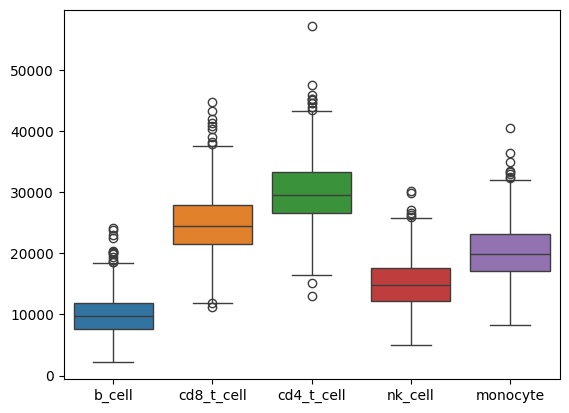

In [107]:
sns.boxplot(df.drop(columns="subject").set_index(["response"]))

<Axes: xlabel='subject'>

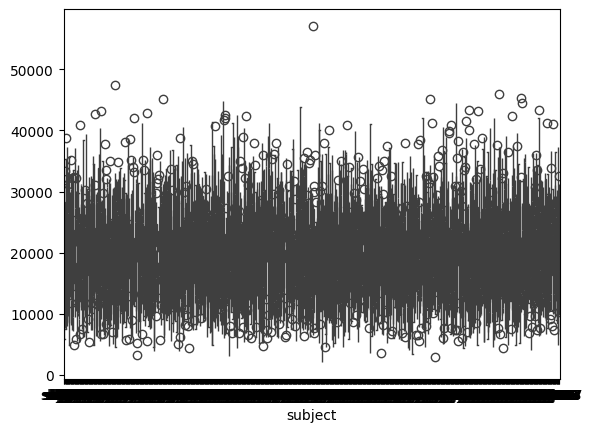

In [102]:
sns.boxplot(df.set_index(["subject", "response"]).unstack("response").T)